In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
from pathlib import Path

from scaling.io import load_results

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

In [2]:
RESULT_FILES = {
    "SEM Laplace": "results/2026-04-01_16h49_sem_laplace/results.csv",
    "SEM Gaussian": "results/2026-04-02_10h34_sem_gaussian/results.csv",
    "CBN Unif-Gauss": "results/2026-04-02_17h41_cbn_unif_gauss/results.csv",
    "CBN Exp-Clayton": "results/2026-04-03_03h56_cbn_exp_clayton/results.csv",
    "CBN Unif-Mixture": "results/2026-04-03_12h05_cbn_unif_mixture/results.csv",
}

dfs = {name: load_results(path) for name, path in RESULT_FILES.items()}

In [3]:
def pareto_ranking(scores: pd.DataFrame) -> list[list[str]]:
    """
    Iteratively extract Pareto fronts to rank algorithms.

    Parameters
    ----------
    scores : DataFrame with columns ['algo', 'SHD', 'F1-Score'].
        SHD is to be minimised, F1-Score maximised.

    Returns
    -------
    list of lists: each inner list is a Pareto tier (best first),
    sub-sorted by F1 descending within the tier.
    """
    remaining = scores.set_index("algo")[["SHD", "F1-Score"]].copy()
    tiers = []

    while len(remaining) > 0:
        # An algo is Pareto-optimal if no other algo has both
        # lower-or-equal SHD AND higher-or-equal F1 (with >= 1 strict).
        dominated = set()
        for a in remaining.index:
            for b in remaining.index:
                if a == b:
                    continue
                if (remaining.loc[b, "SHD"] <= remaining.loc[a, "SHD"]
                        and remaining.loc[b, "F1-Score"] >= remaining.loc[a, "F1-Score"]
                        and (remaining.loc[b, "SHD"] < remaining.loc[a, "SHD"]
                             or remaining.loc[b, "F1-Score"] > remaining.loc[a, "F1-Score"])):
                    dominated.add(a)
                    break
        front = [a for a in remaining.index if a not in dominated]
        # Sub-sort by F1 descending
        front = sorted(front, key=lambda a: remaining.loc[a, "F1-Score"], reverse=True)
        tiers.append(front)
        remaining = remaining.drop(front)

    return tiers


def format_ranking(tiers: list[list[str]]) -> str:
    """Pretty-print a Pareto ranking."""
    parts = []
    for tier in tiers:
        parts.append(" >(f1) ".join(tier))
    return " >(pareto) ".join(parts)

## Rankings by dataset and configuration

In [4]:
all_rankings = []

for ds_name, df in dfs.items():
    subset = df[df["n_samples"] == 5000]
    for n_vars in sorted(subset["n_vars"].unique()):
        sub = subset[subset["n_vars"] == n_vars]
        scores = sub.groupby("algo")[["SHD", "F1-Score"]].mean().reset_index()
        tiers = pareto_ranking(scores)
        all_rankings.append({
            "dataset": ds_name,
            "n_vars": n_vars,
            "ranking": format_ranking(tiers),
            "tiers": tiers,
        })

ranking_df = pd.DataFrame(all_rankings)
pd.set_option("display.max_colwidth", None)
ranking_df[["dataset", "n_vars", "ranking"]]

,dataset,n_vars,ranking
0,SEM Laplace,10,LiNGAM >(pareto) NOTEARS >(pareto) CPC >(f1) NOTEARS Disc. >(pareto) MIIC >(pareto) CMIIC >(pareto) GHC+BDeu
1,SEM Laplace,20,LiNGAM >(pareto) NOTEARS >(pareto) MIIC >(pareto) NOTEARS Disc. >(pareto) CMIIC >(pareto) CPC >(pareto) GHC+BDeu
2,SEM Gaussian,10,NOTEARS >(pareto) CPC >(f1) NOTEARS Disc. >(pareto) MIIC >(pareto) LiNGAM >(f1) GHC+BDeu >(f1) CMIIC
3,SEM Gaussian,20,NOTEARS >(pareto) MIIC >(pareto) NOTEARS Disc. >(pareto) CPC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) LiNGAM
4,CBN Unif-Gauss,10,NOTEARS Disc. >(f1) CPC >(pareto) LiNGAM >(f1) CMIIC >(f1) MIIC >(pareto) GHC+BDeu >(pareto) NOTEARS
5,CBN Unif-Gauss,20,NOTEARS Disc. >(pareto) MIIC >(pareto) CPC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) LiNGAM >(f1) NOTEARS
6,CBN Exp-Clayton,10,CPC >(pareto) LiNGAM >(f1) NOTEARS Disc. >(f1) MIIC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) NOTEARS
7,CBN Exp-Clayton,20,NOTEARS Disc. >(pareto) CPC >(f1) MIIC >(pareto) CMIIC >(pareto) LiNGAM >(f1) GHC+BDeu >(pareto) NOTEARS
8,CBN Unif-Mixture,10,MIIC >(pareto) CPC >(f1) GHC+BDeu >(pareto) LiNGAM >(f1) CMIIC >(pareto) NOTEARS Disc. >(pareto) NOTEARS
9,CBN Unif-Mixture,20,MIIC >(pareto) CPC >(pareto) GHC+BDeu >(pareto) LiNGAM >(f1) CMIIC >(pareto) NOTEARS Disc. >(pareto) NOTEARS


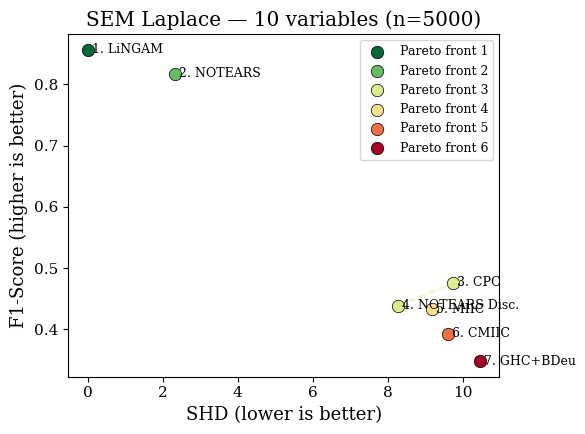

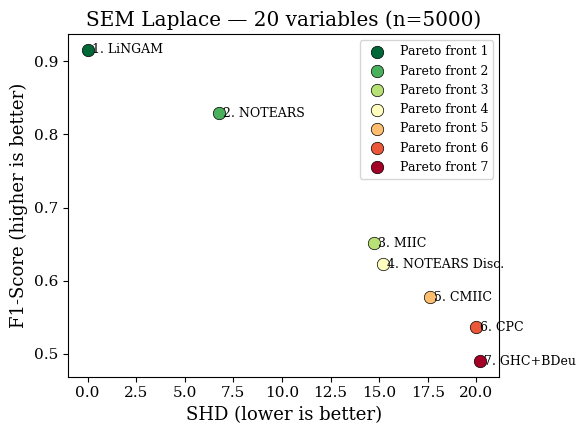

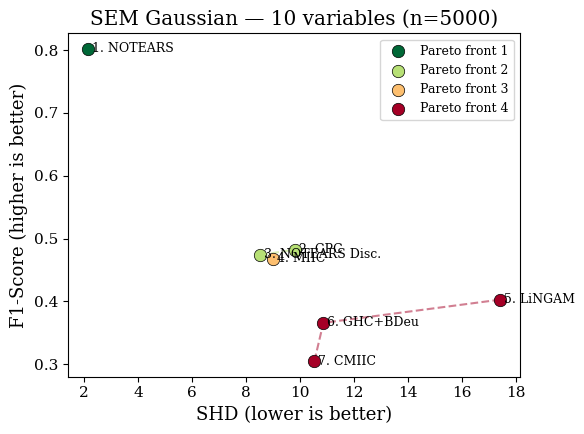

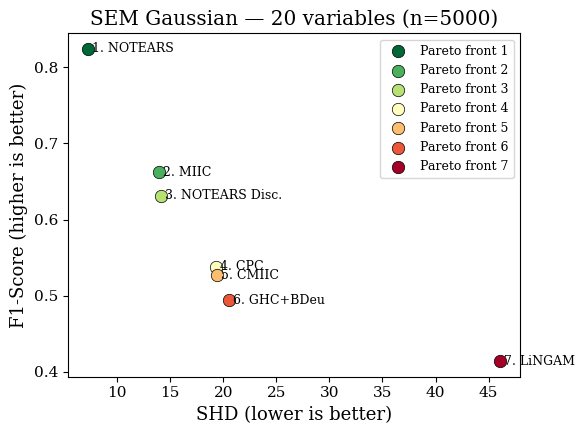

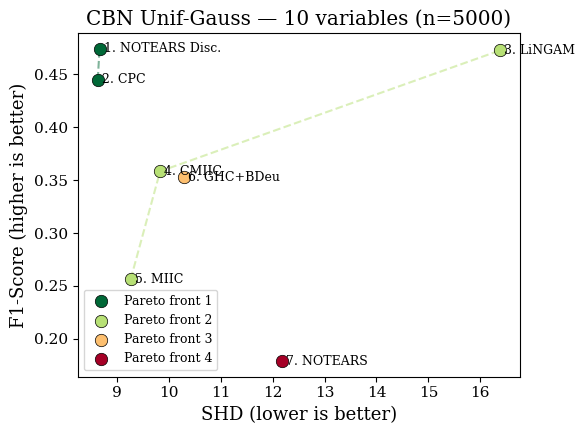

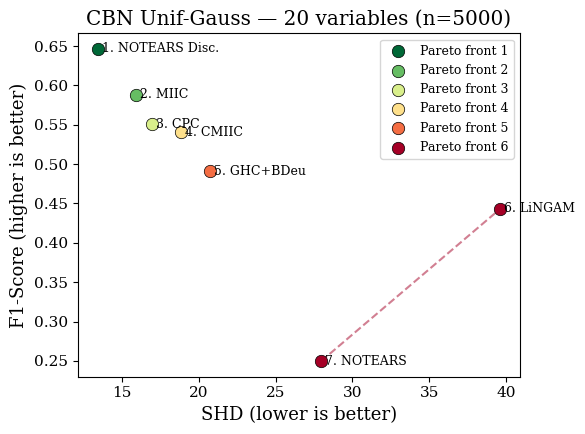

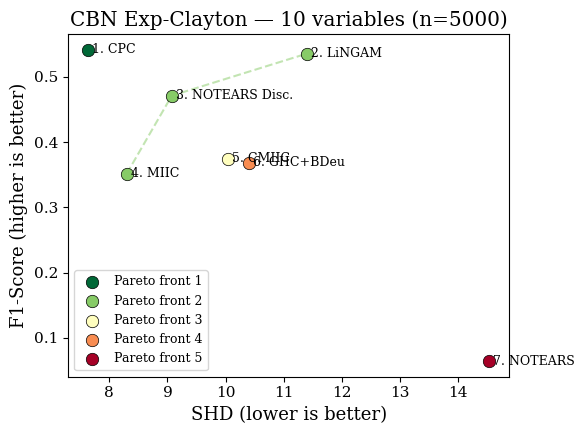

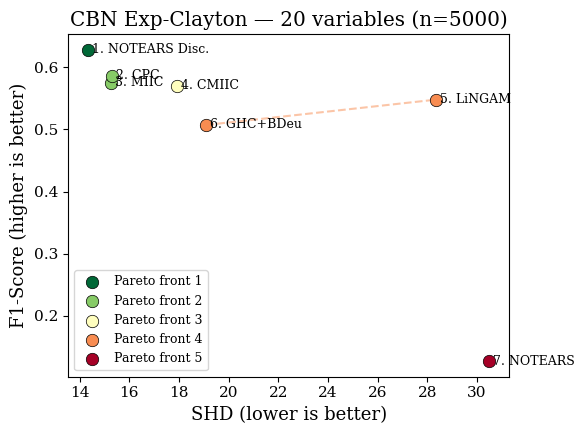

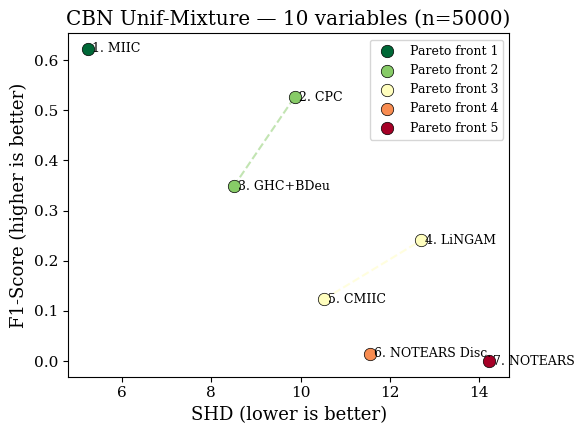

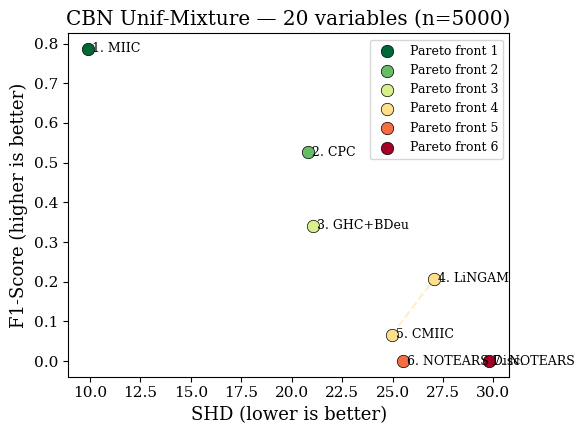

In [5]:
TIER_COLORS = plt.cm.RdYlGn_r  # red = worst, green = best (reversed)

for row in all_rankings:
    ds_name = row["dataset"]
    n_vars = row["n_vars"]
    tiers = row["tiers"]
    n_tiers = len(tiers)

    # Recover mean scores
    df = dfs[ds_name]
    subset = df[(df["n_samples"] == 5000) & (df["n_vars"] == n_vars)]
    scores = subset.groupby("algo")[["SHD", "F1-Score"]].mean()

    fig, ax = plt.subplots(figsize=(6, 4.5))

    # Assign global rank for labelling
    global_rank = {}
    r = 1
    for tier in tiers:
        for algo in tier:
            global_rank[algo] = r
            r += 1

    # Plot each Pareto tier with a different color + connecting line
    for tier_idx, tier in enumerate(tiers):
        color = TIER_COLORS(tier_idx / max(n_tiers - 1, 1))
        tier_scores = scores.loc[tier].sort_values("SHD")
        ax.plot(
            tier_scores["SHD"], tier_scores["F1-Score"],
            "--", color=color, alpha=0.5, linewidth=1.5, zorder=1,
        )
        ax.scatter(
            tier_scores["SHD"], tier_scores["F1-Score"],
            color=color, s=80, zorder=2, edgecolors="black", linewidths=0.5,
            label=f"Pareto front {tier_idx + 1}",
        )

    # Annotate each point with rank and algo name
    for algo, rank in global_rank.items():
        x, y = scores.loc[algo, "SHD"], scores.loc[algo, "F1-Score"]
        ax.annotate(
            f" {rank}. {algo}", (x, y),
            fontsize=9, va="center", ha="left",
        )

    ax.set_xlabel("SHD (lower is better)")
    ax.set_ylabel("F1-Score (higher is better)")
    ax.set_title(f"{ds_name} — {n_vars} variables (n=5000)")
    ax.legend(fontsize=9, frameon=True)
    fig.tight_layout()
    plt.show()

## Aggregate ranking scores

Assign a rank (1 = best) to each algorithm in each configuration, then average across all configurations.

In [6]:
# Build a table: for each config, assign rank 1..N to each algo
rank_records = []
for row in all_rankings:
    rank = 1
    for tier in row["tiers"]:
        for algo in tier:
            rank_records.append({
                "dataset": row["dataset"],
                "n_vars": row["n_vars"],
                "algo": algo,
                "rank": rank,
            })
            rank += 1

rank_df = pd.DataFrame(rank_records)

# Average rank per algo
avg_rank = rank_df.groupby("algo")["rank"].mean().sort_values()
print("Average rank across all configurations (n_samples=5000):")
print(avg_rank.to_string())

Average rank across all configurations (n_samples=5000):
algo
CPC              2.7
MIIC             3.0
NOTEARS Disc.    3.2
LiNGAM           3.8
NOTEARS          4.8
CMIIC            5.0
GHC+BDeu         5.5


In [7]:
# Average rank per algo, per dataset
pivot = rank_df.pivot_table(index="algo", columns="dataset", values="rank", aggfunc="mean")
pivot["Overall"] = avg_rank
pivot = pivot.sort_values("Overall")
pivot.round(2)

dataset,CBN Exp-Clayton,CBN Unif-Gauss,CBN Unif-Mixture,SEM Gaussian,SEM Laplace,Overall
algo,,,,,,
CPC,1.5,2.5,2.0,3.0,4.5,2.7
MIIC,3.5,3.5,1.0,3.0,4.0,3.0
NOTEARS Disc.,2.0,1.0,6.0,3.0,4.0,3.2
LiNGAM,3.5,4.5,4.0,6.0,1.0,3.8
NOTEARS,7.0,7.0,7.0,1.0,2.0,4.8
CMIIC,4.5,4.0,5.0,6.0,5.5,5.0
GHC+BDeu,6.0,5.5,3.0,6.0,7.0,5.5
